In [ ]:
import zipfile

with zipfile.ZipFile("UCI HAR Dataset.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import os

print(os.listdir("UCI HAR Dataset"))

['activity_labels.txt', 'train', 'test', 'features.txt', 'README.txt', '.DS_Store', 'features_info.txt']


In [ ]:
import pandas as pd

x_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    sep=r"\s+",
    header=None
)

x_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    sep=r"\s+",
    header=None
)


In [ ]:
print("X_train:", x_train.shape)
print("y_train:", y_train.shape)
print("X_test:", x_test.shape)
print("y_test:", y_test.shape)

X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)


In [ ]:
print("Training data:")
print(x_train.head())

print("\nTraining labels:")
print(y_train.head())

print("\nFeature values:")
print(x_train.dtypes.value_counts())

print("\nUnique activity labels:")
print(sorted(y_train[0].unique()))

print("\nMissing values in X_train:", x_train.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum().sum())

Training data:
        0         1         2         3         4         5         6    \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

        7         8         9    ...       551       552       553       554  \
0 -0.983185 -0.923527 -0.934724  ... -0.074323 -0.298676 -0.710304 -0.112754   
1 -0.974914 -0.957686 -0.943068  ...  0.158075 -0.595051 -0.861499  0.053477   
2 -0.963668 -0.977469 -0.938692  ...  0.414503 -0.390748 -0.760104 -0.118559   
3 -0.982750 -0.989302 -0.938692  ...  0.404573 -0.117290 -0.482845 -0.036788   
4 -0.979672 -0.990441 -0.942469  ...  0.087753 -0.351471 -0.699205  0.123320   

        555       556       557       558       559  

In [ ]:
feature_names = pd.read_csv(
    "UCI HAR Dataset/features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

print(feature_names.head(20))
print("\nTotal features:", len(feature_names))

    index              feature
0       1    tBodyAcc-mean()-X
1       2    tBodyAcc-mean()-Y
2       3    tBodyAcc-mean()-Z
3       4     tBodyAcc-std()-X
4       5     tBodyAcc-std()-Y
5       6     tBodyAcc-std()-Z
6       7     tBodyAcc-mad()-X
7       8     tBodyAcc-mad()-Y
8       9     tBodyAcc-mad()-Z
9      10     tBodyAcc-max()-X
10     11     tBodyAcc-max()-Y
11     12     tBodyAcc-max()-Z
12     13     tBodyAcc-min()-X
13     14     tBodyAcc-min()-Y
14     15     tBodyAcc-min()-Z
15     16       tBodyAcc-sma()
16     17  tBodyAcc-energy()-X
17     18  tBodyAcc-energy()-Y
18     19  tBodyAcc-energy()-Z
19     20     tBodyAcc-iqr()-X

Total features: 561


In [ ]:
x_train.columns = feature_names["feature"]
x_test.columns = feature_names["feature"]

In [ ]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train.to_numpy(), y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [ ]:
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best CV accuracy: 0.9358076554891162


Final Test Accuracy: 0.9616559212758737

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       496
           2       0.96      0.96      0.96       471
           3       0.99      0.95      0.97       420
           4       0.96      0.89      0.92       491
           5       0.91      0.97      0.94       532
           6       1.00      1.00      1.00       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947


Confusion Matrix:
[[495   0   1   0   0   0]
 [ 16 453   2   0   0   0]
 [  6  15 399   0   0   0]
 [  0   2   0 436  53   0]
 [  0   0   0  18 514   0]
 [  0   0   0   0   0 537]]


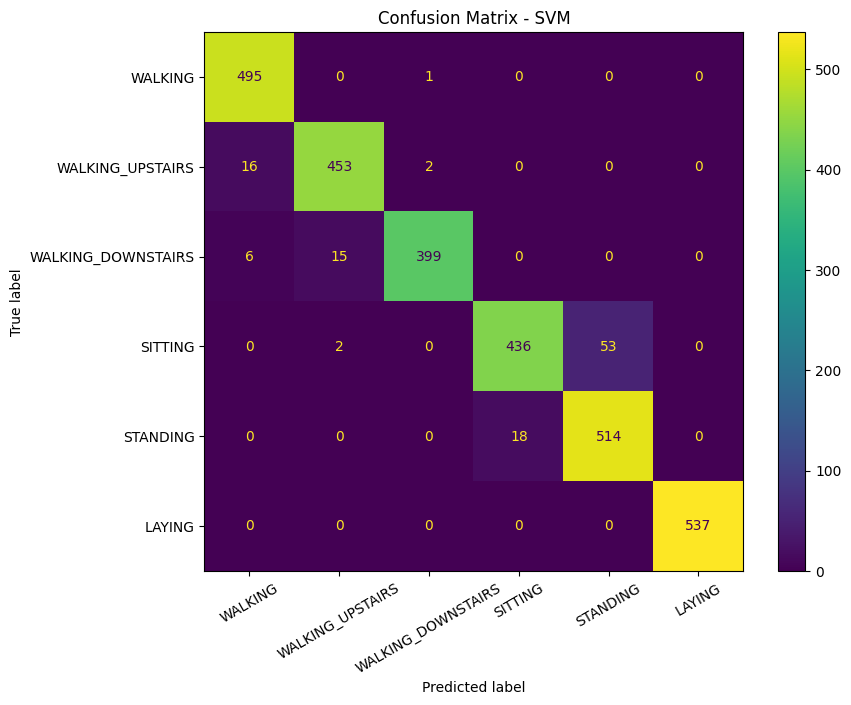

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the best model from GridSearch
best_model = grid_search.best_estimator_

# Predict using NumPy array
y_test_pred = best_model.predict(x_test.to_numpy())

# Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "WALKING",
        "WALKING_UPSTAIRS",
        "WALKING_DOWNSTAIRS",
        "SITTING",
        "STANDING",
        "LAYING"
    ]
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=30)

plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
import joblib
joblib.dump(best_model, "har_svm_model.joblib")

['har_svm_model.joblib']

In [ ]:
sample_X = x_test.iloc[[0]]
sample_Y = y_test.iloc[0]

sample_X.to_csv("sample_data.csv", index=False)

with open("sample_label.txt", "w") as f:
    f.write(str(sample_Y))